In [1]:
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from astropy.modeling import models
from scipy.signal import convolve
from scipy.optimize import minimize
from astropy.convolution import Gaussian1DKernel
import scipy.integrate as integrate
from scipy.optimize import differential_evolution
import pandas as pd
import os

In [2]:
hdul = fits.open("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits")
hdul.info()
image = hdul[0].data
image_error = hdul[1].data

Filename: C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/Mrk_544/FORS2.2021-08-21T05_32_16.048/Reduced/Mrk-544_MAPPED_FLUX_SCI_LSS_U1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     365   (2094, 964)   float32   
  1  IMAGE.ERR     1 ImageHDU        46   (2094, 964)   float32   


In [3]:
image_cut = image[55:155, 0:1800]
image_error_cut = image_error[55:155, 0:1800]
wavelenghts = np.arange(4300.74, 4300.74+1800*1.48, 1.48)
J, N = image_cut.data.shape
#x = np.arange(0, N, 1)
y = np.arange(0, J, 1)
arcsec_y = np.arange(-58*0.256, 42*0.256, 0.256)

z = 0.0238
l_HA = 6563 * (1+z)
l_HB = 4861 * (1+z) 
l_NII = 6583 * (1+z)
l_SII = 6717 * (1+z)
l_OIII = 5007 * (1+z)

In [4]:
def calculate_bn(n):
    """ Calcola b_n per il profilo Sérsic """
    return 2*n - 1/3 + 4/(405*n) + 46/(25515*n**2)

def sersic_1d(x, params):
    """ Profilo Sérsic 1D centrato in x_0 """
    I_e, r_e, n, x_0 = params
    r = np.abs(x - x_0)
    b_n = calculate_bn(n)
    return I_e * np.exp(-b_n * ((r / r_e)**(1 / n) - 1))
    
def sersic_1d_convolved(x, params):
    """ Sérsic convoluto con PSF gaussiana """
    profile = sersic_1d(x, params)
    psf = Gaussian1DKernel(stddev = sigma, mode='center')
    conv_profile = convolve(profile, psf, mode='same')
    return conv_profile

def model_convolved(x, params1, params2, params3, params4):
    x_hr = np.linspace(min(x), max(x), 4000)
    profile = (
        sersic_1d(x_hr, params1) +
        sersic_1d(x_hr, params2) +
        sersic_1d(x_hr, params3) +
        sersic_1d(x_hr, params4)
    )
    kernel = Gaussian1DKernel(stddev=(sigma*len(x_hr))/len(x), x_size=len(x_hr), mode='center')   
    conv_profile = convolve(profile, kernel, mode='same')
    conv_profile_out = np.interp(x, x_hr, conv_profile)
    return conv_profile_out

Text(0.5, 1.0, 'H$\\alpha$')

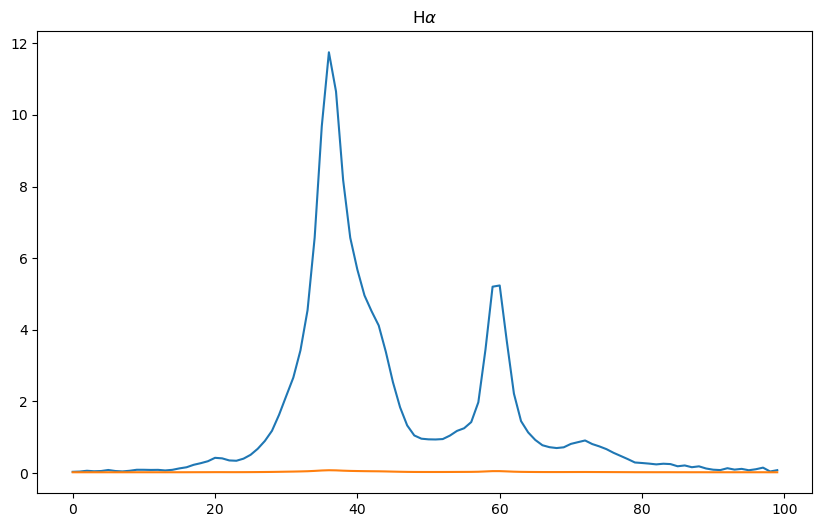

In [5]:
mask_HA = (wavelenghts > l_HA-8)*(wavelenghts < l_HA+8)
image_HA = image_cut[:, mask_HA]
image_error_HA = image_error_cut[:, mask_HA]
radial_profile_HA = np.sum(image_HA, axis = 1)
radial_profile_error_HA = np.sqrt(np.sum(image_error_HA**2, axis = 1))

x_axes = np.arange(0, 100, 1)
plt.figure(figsize=(10, 6))
plt.plot(x_axes, radial_profile_HA)
plt.plot(x_axes, radial_profile_error_HA)
plt.title(r'H$\alpha$')

In [ ]:
def colored_line_between_pts(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified between (x, y) points by a third value.

    It does this by creating a collection of line segments between each pair of
    neighboring points. The color of each segment is determined by the
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should have a size one less than that of x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Check color array size (LineCollection still works, but values are unused)
    if len(c) != len(x) - 1:
        warnings.warn(
            "The c argument should have a length one less than the length of x and y. "
            "If it has the same length, use the colored_line function instead."
        )

    # Create a set of line segments so that we can color them individually
    # This creates the points as an N x 1 x 2 array so that we can stack points
    # together easily to get the segments. The segments array for line collection
    # needs to be (numlines) x (points per line) x 2 (for x and y)
    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = LineCollection(segments, **lc_kwargs)

    # Set the values used for colormapping
    lc.set_array(c)

    return ax.add_collection(lc)

In [ ]:
# -------------- Create and show plot --------------
dydx = np.cos(0.5 * (x[:-1] + x[1:]))  # first derivative

fig2, ax2 = plt.subplots()
line = colored_line_between_pts(x_axes, radial_profile_HA, dydx, ax2, linewidth=2, cmap="viridis")
fig2.colorbar(line, ax=ax2, label="dy/dx")

ax2.set_xlim(x.min(), x.max())
ax2.set_ylim(-1.1, 1.1)
ax2.set_title("Color between points")

plt.show()